# Data Analysis: US Census (2010 - 2019)

- **Objective**: Data Analysis can be approached *bottom-up* — we start with the data and look for something interesting.
- **Dataset**: The [US Census 2010–2019](https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.pdf) — *Annual Estimates of the Resident Population by Single Year of Age and Sex for the United States*.
- **Estimated time**: 30 minutes.

## Loading the Data

We start by locating the CSV file on disk and loading it into a `pandas` DataFrame.

In [1]:
# Modern, cross-platform way to handle filesystem paths.
# Docs: https://docs.python.org/3/library/pathlib.html
from pathlib import Path

# The original online source (kept here as a reference, but we use a local copy):
# 'http://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.csv'
#
# `Path('../data') / 'nc-est2019-agesex-res.csv'` builds the path "../data/nc-est2019-agesex-res.csv"
# using the OS-appropriate separator — no string concatenation needed.
file_path = Path('../data') / 'nc-est2019-agesex-res.csv'

# Quick sanity check: does the file actually exist where we expect it?
print(file_path.exists())

True


In [2]:
# pandas is the standard Python library for tabular ("DataFrame") data.
# Docs: https://pandas.pydata.org/docs/
import pandas as pd

# `read_csv` parses the CSV file into a DataFrame — a 2-D table with labelled columns.
full_census_df = pd.read_csv(file_path)

# `.head(n)` returns the first n rows — perfect for getting a feel for the shape
# of the data without printing 300+ lines.
full_census_df.head(10)

,SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
1,0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
2,0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
3,0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
4,0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
5,0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
6,0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
7,0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
8,0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
9,0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874


## Table Description

A [description of the table](https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.pdf) appears online. 

The `SEX` column contains numeric codes:
- `0` stands for the total
- `1` for male
- `2` for female

The `AGE` column contains ages in completed years
- the special value `999` is a sum of the total population
- the value `100` is actually `100+`

## Attribute Selection

Suppose we are only interested in the population changes from 2014 to 2019. Let's `select` the relevant columns.

In [3]:
# Pass a *list* of column names (note the double brackets `[[ ... ]]`)
# to get a new DataFrame with only the four columns we care about.
# The original `full_census_df` is left untouched.
partial_census_df = full_census_df[['SEX', 'AGE', 'POPESTIMATE2014', 'POPESTIMATE2019']]
partial_census_df

,SEX,AGE,POPESTIMATE2014,POPESTIMATE2019
0,0,0,3954787,3783052
1,0,1,3948891,3829599
2,0,2,3958711,3922044
3,0,3,4005928,3998665
4,0,4,4004032,4043323
...,...,...,...,...
301,2,97,62407,84358
302,2,98,45887,62607
303,2,99,32245,42528
304,2,100,57108,76850


## Attribute Renaming

We can simplify the labels of the selected columns.

In [4]:
# `.rename()` returns a NEW DataFrame with renamed columns — it does NOT
# mutate `partial_census_df`. The mapping is {old_name: new_name}.
us_pop = partial_census_df.rename(
    columns={
        'POPESTIMATE2014': '2014',   # shorten the verbose label to just the year
        'POPESTIMATE2019': '2019',
    }
)

In [5]:
us_pop

,SEX,AGE,2014,2019
0,0,0,3954787,3783052
1,0,1,3948891,3829599
2,0,2,3958711,3922044
3,0,3,4005928,3998665
4,0,4,4004032,4043323
...,...,...,...,...
301,2,97,62407,84358
302,2,98,45887,62607
303,2,99,32245,42528
304,2,100,57108,76850


## Row Filtering

### Filtering by `SEX`

- Boolean masks let us keep only the rows we care about.
- We will first show the mechanics on **males (`SEX == 1`)**, then use the same pattern to keep just the **totals (`SEX == 0`)**, where the `SEX` column becomes redundant and can be dropped.

In [6]:
# Quick demo of boolean filtering before we use it "for real" below.
#
# Step 1 — build a *boolean mask*: a Series of True/False values, one per row,
#          that is True where the row's SEX is 1 (male).
mask = us_pop['SEX'] == 1

# Step 2 — indexing the DataFrame with the mask keeps only the rows where
#          the mask is True (i.e. the male rows).
us_pop[mask]

,SEX,AGE,2014,2019
102,1,0,2024511,1935117
103,1,1,2018511,1958585
104,1,2,2023752,2005544
105,1,3,2049250,2043010
106,1,4,2043524,2066951
...,...,...,...,...
199,1,97,20541,32611
200,1,98,13659,23543
201,1,99,9032,14596
202,1,100,13577,23472


In [7]:
# Same idea, broken into named steps for clarity (instead of one
# long `us_pop[us_pop['SEX']==0].drop(...)` chain).

# Mask the rows that hold totals (SEX code 0 = both sexes combined).
total_pop_mask = us_pop['SEX'] == 0

# Keep only those "total" rows.
total_pop_rows = us_pop[total_pop_mask]

# After this filter every row has SEX == 0, so the column is redundant — drop it.
us_pop_by_age = total_pop_rows.drop(columns='SEX')

us_pop_by_age

,AGE,2014,2019
0,0,3954787,3783052
1,1,3948891,3829599
2,2,3958711,3922044
3,3,4005928,3998665
4,4,4004032,4043323
...,...,...,...
97,97,82948,116969
98,98,59546,86150
99,99,41277,57124
100,100,70685,100322


### Highest Ages (97–100)

Now let's look at the population in the highest ages.

In [8]:
# We want the oldest reported ages: 97, 98, 99, 100.
# Build two single-condition masks…
at_least_97 = us_pop_by_age['AGE'] >= 97
at_most_100 = us_pop_by_age['AGE'] <= 100

# …and combine them with `&` (element-wise AND) to get the intersection.
# (Note: `and` would NOT work here — pandas needs the bit-wise `&`.)
mask = at_least_97 & at_most_100

us_pop_by_age[mask]

,AGE,2014,2019
97,97,82948,116969
98,98,59546,86150
99,99,41277,57124
100,100,70685,100322


## Calculate New Attributes (Add Columns)

In [9]:
# Subtracting two columns happens *element-wise* in pandas:
# the result is a new Series with one value per age, showing the
# raw change in population between 2014 and 2019.
us_pop_by_age['2019'] - us_pop_by_age['2014']

0      -171735
1      -119292
2       -36667
3        -7263
4        39291
        ...   
97       34021
98       26604
99       15847
100      29637
101    9938515
Length: 102, dtype: int64

In [10]:
# Compute the absolute change once and reuse it twice below.
change = us_pop_by_age['2019'] - us_pop_by_age['2014']

# `.assign()` returns a NEW DataFrame with the extra columns attached —
# safer than mutating `us_pop_by_age` in place.
us_pop_change = us_pop_by_age.assign(
    Change=change,                                  # raw difference (people)
    Percent_Change=change / us_pop_by_age['2014'],  # difference as a fraction of the 2014 base
)

# `.map()` applies a function to each value in the Series.
# Here we convert a fraction (e.g. 0.0312) into a human-readable
# percentage string (e.g. "3.12%") using an f-string format spec.
us_pop_change['Percent_Change'] = us_pop_change['Percent_Change'].map(
    lambda fraction: f"{fraction:.2%}"
)

us_pop_change

,AGE,2014,2019,Change,Percent_Change
0,0,3954787,3783052,-171735,-4.34%
1,1,3948891,3829599,-119292,-3.02%
2,2,3958711,3922044,-36667,-0.93%
3,3,4005928,3998665,-7263,-0.18%
4,4,4004032,4043323,39291,0.98%
...,...,...,...,...,...
97,97,82948,116969,34021,41.01%
98,98,59546,86150,26604,44.68%
99,99,41277,57124,15847,38.39%
100,100,70685,100322,29637,41.93%


Almost all the entries displayed in the `Percent Change` column are negative, demonstrating a drop in population at the youngest ages. However, the overall population (`AGE=999`) grew by about 9.9 million people, a percent change of just over 3%.

In [11]:
# `AGE == 999` is the special "all ages" summary row.
# Looking at it gives us the country-wide totals and overall growth rate.
us_pop_change[us_pop_change['AGE'] == 999]

,AGE,2014,2019,Change,Percent_Change
101,999,318301008,328239523,9938515,3.12%


Let us compare this to the change at each age. For ease of interpretation, we will sort the table in decreasing order of the absolute change in population, contained in the column `Change`.

In [12]:
# Instead of one long chain
# `us_pop_change[us_pop_change['AGE'] != 999].sort_values(...).head()`
# we split it into three named steps so each transformation is obvious.

# 1. Drop the "all ages" summary row — we want to rank individual ages.
real_ages = us_pop_change[us_pop_change['AGE'] != 999]

# 2. Sort by raw change descending, so the biggest growers come first.
sorted_by_change = real_ages.sort_values(by='Change', ascending=False)

# 3. Show only the top of the ranking.
sorted_by_change.head()

,AGE,2014,2019,Change,Percent_Change
72,72,2191642,3191048,999406,45.60%
68,68,2567511,3345475,777964,30.30%
69,69,2530460,3252423,721963,28.53%
70,70,2461426,3136704,675278,27.43%
71,71,2516392,3083083,566691,22.52%


Read more [about sorting basics](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-sorting).

### The "Greying of America"

- The overall percent change is about **3%**, but for people in their late sixties and early seventies it jumps to **well over 20%** — the so-called *greying of America*.
- Why? Compare the birth years of the relevant cohorts:
  - People aged **69–72 in 2014** were born in **1942–1945**, the WWII years (low birth rates during the war).
  - People aged **69–72 in 2019** were born in **1947–1950**, the peak of the **post-WWII baby boom**.
- **The post-war jump in births is a major reason for the large changes we observe.**

## Example: Sex Ratios

This time we will focus on population trends in relation to the `SEX` column.

### Overall Proportions in 2019

In [13]:
# We no longer need 2014, so drop it. From here on we work with a 2019 snapshot.
us_pop_2019 = us_pop.drop(columns=['2014'])

# Pull the "all ages" summary rows (AGE == 999) — broken into two steps
# so the boolean mask is named and the drop is independent.
all_ages_mask = us_pop_2019['AGE'] == 999
all_ages = us_pop_2019[all_ages_mask].drop(columns='AGE')

all_ages

,SEX,2019
101,0,328239523
203,1,161657324
305,2,166582199


Calculate proportions relative to total population in 2019:

In [14]:
# `.iloc[0]` picks the first row by position; `['2019']` grabs the value
# in the 2019 column. That row is the grand total (SEX==0 / "both sexes").
pop_2019 = all_ages.iloc[0]['2019']

# Work on an explicit copy so pandas doesn't warn about modifying a slice
# of the parent DataFrame.
all_ages = all_ages.copy()

# Compute each row's share of the total and format it as a percent string.
proportions = all_ages['2019'] / pop_2019
all_ages['Proportion'] = proportions.map(lambda fraction: f"{fraction:.2%}")

all_ages

,SEX,2019,Proportion
101,0,328239523,100.00%
203,1,161657324,49.25%
305,2,166582199,50.75%


### Proportions Among Infants

When we look at infants, however, the opposite is true. Let’s define infants to be babies who have not yet completed one year, represented in the rows corresponding to `AGE 0`. Here are their numbers in the population. You can see that male infants outnumbered female infants.

In [15]:
# Build the infant table by splitting the long chain into named pieces.

# 1. Mask the infant rows (those with AGE == 0).
infant_mask = us_pop_2019['AGE'] == 0

# 2. Keep those rows, drop the now-constant AGE column, and make an
#    explicit copy so we can safely add a new column below.
infants = us_pop_2019[infant_mask].drop(columns='AGE').copy()

# 3. Total infant population sits at original index 0 (SEX == 0 / both sexes).
infants_2019 = infants.loc[0, '2019']

# Compute each row's share of the total infant population.
infant_proportions = infants['2019'] / infants_2019
infants['Proportion'] = infant_proportions.map(lambda fraction: f"{fraction:.2%}")

infants

,SEX,2019,Proportion
0,0,3783052,100.00%
102,1,1935117,51.15%
204,2,1847935,48.85%


As before, we can convert these counts to percents out of the total numbers of infants. The resulting table shows that in 2019, just over 51% of infants in the U.S. were male. 

In fact, it has long been observed that the proportion of males among newborns is slightly more than 1/2. The reason for this is not thoroughly understood.

### Sex Ratio at Each Age

While there are more male infants than female, there are more females than males in the population overall.

In [16]:
# The original one-liner nested four parenthesised expressions; we split it.
#
# Skip the "all ages" summary row so we get exactly one row per individual age.
real_ages_mask = us_pop_2019['AGE'] != 999

# Female rows: SEX == 2, individual ages only.
# `reset_index(drop=True)` re-numbers rows 0..N so the female and male
# tables line up perfectly for column-wise arithmetic below.
female_mask = (us_pop_2019['SEX'] == 2) & real_ages_mask
females = us_pop_2019[female_mask].reset_index(drop=True)

# Male rows: SEX == 1, in the same row order as `females`.
male_mask = (us_pop_2019['SEX'] == 1) & real_ages_mask
males = us_pop_2019[male_mask].reset_index(drop=True)

females

,SEX,AGE,2019
0,2,0,1847935
1,2,1,1871014
2,2,2,1916500
3,2,3,1955655
4,2,4,1976372
...,...,...,...
96,2,96,111417
97,2,97,84358
98,2,98,62607
99,2,99,42528


In [17]:
# Start from the female table (AGE + 2019 population).
# `.copy()` makes sure adding a column below modifies our own DataFrame,
# not a view into the parent (avoids SettingWithCopyWarning).
ratios = females[['AGE', '2019']].copy()

# Because `females` and `males` share the same row order (thanks to
# reset_index above), dividing column-by-column gives the female-to-male
# ratio at each age.
ratios['2019 F:M RATIO'] = ratios['2019'] / males['2019']

ratios

,AGE,2019,2019 F:M RATIO
0,0,1847935,0.954947
1,1,1871014,0.955289
2,2,1916500,0.955601
3,3,1955655,0.957242
4,4,1976372,0.956177
...,...,...,...
96,96,111417,2.419689
97,97,84358,2.586796
98,98,62607,2.659262
99,99,42528,2.913675


In [18]:
# Zoom in on the older end of the distribution where the F:M ratio rises sharply
# (women tend to outlive men, so the ratio climbs steadily after midlife).
ratios_above_75 = ratios[ratios['AGE'] > 75]
ratios_above_75

,AGE,2019,2019 F:M RATIO
76,76,1218702,1.214222
77,77,1056331,1.235576
78,78,960647,1.263727
79,79,898590,1.281286
80,80,831640,1.292093
81,81,788013,1.327453
82,82,715575,1.361014
83,83,671025,1.397488
84,84,631230,1.446027
85,85,551385,1.485885


### Visualizing the F:M Ratio

Finally, let's plot the ratio against age to see the trend at a glance.

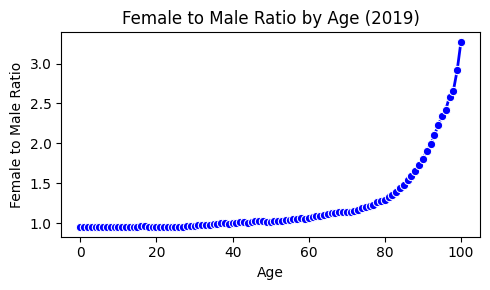

In [20]:
# matplotlib — low-level Figure/Axes plotting.
# Docs: https://matplotlib.org/stable/api/index.html
import matplotlib.pyplot as plt

# seaborn — high-level statistical plots built on top of matplotlib.
# Docs: https://seaborn.pydata.org/
import seaborn as sns

# Create our own Figure + Axes so we have full control over the canvas.
# `figsize` is (width_inches, height_inches).
fig, ax = plt.subplots(figsize=(5, 3))

# Draw the F:M ratio vs. AGE as a line plot.
sns.lineplot(
    data=ratios,             # the DataFrame holding our data
    x='AGE',                 # column name to put on the x-axis (ages 0..100)
    y='2019 F:M RATIO',      # column name to put on the y-axis (the ratio we computed)
    marker='o',              # draw a small circle at each data point
    color='b',               # line + marker colour ('b' is matplotlib shorthand for blue)
    linewidth=2,             # thickness of the connecting line, in points
    ax=ax,                   # draw onto the Axes we created above (not a new one)
)

# Replace the technical column names with friendly axis labels.
ax.set_xlabel('Age')
ax.set_ylabel('Female to Male Ratio')
ax.set_title('Female to Male Ratio by Age (2019)')

# `tight_layout()` trims excess whitespace;
fig.tight_layout()